## **Business Understanding**

In [1]:

import pandas as pd #for data manipulation and reading the data frame
from sklearn.linear_model import LinearRegression# we use sklearn as it cmposes many ML algorithms that w can use for our model
from sklearn.model_selection import train_test_split # we split the data into training and testing data
import seaborn as sns #for data visualization
from sklearn.metrics import r2_score #to check the accuracy of our model
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt # aids in visualizatio

In [3]:
columns = ["Sex","Length","Diameter","Height","Whole weight","Shucked weight","Viscera weight","Shell weight","Rings"]

In [4]:
df =pd.read_csv("C:\\Users\\USER\\Documents\\ML series\\LinearRegression\\data\\abalone.data",names=columns) #reading the data frame and naming the columns

In [5]:
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore') # instance of the model (transformer based) -
encoder.fit(df[['Sex']]) # fit to get the classes 
encoder.categories_ # lists our categories
encoded_furnishing_status= encoder.transform(df[['Sex']]).toarray()

#  the essence of this DF is basically to represent the valiues in independent features
encoded_df = pd.DataFrame(
    encoded_furnishing_status, 
    columns= encoder.get_feature_names_out(['Sex'])
) 

In [11]:
encoded_df.head()

,Sex_F,Sex_I,Sex_M
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0


In [12]:
df.describe(include="object") #to check the categorical data

C:\Users\USER\AppData\Local\Temp\ipykernel_22920\3743259621.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object") #to check the categorical data


,Sex
count,4177
unique,3
top,M
freq,1528


In [13]:
df.describe(include="all")

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,NaN,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,NaN,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,NaN,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,NaN,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,NaN,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000


In [15]:
# reset the index or first df
df_2 = df.reset_index(drop=True)

# reset index of the encoded df
encoded_df = encoded_df.reset_index(drop=True)

# combine the two df's
df_2 = pd.concat([df_2.drop(columns=['Sex']), encoded_df], axis=1)

In [16]:
df_2.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0.0,0.0,1.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0.0,0.0,1.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,1.0,0.0,0.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0.0,0.0,1.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0.0,1.0,0.0


In [17]:
df_2.describe(include="all")

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_F,Sex_I,Sex_M
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684,0.312904,0.321283,0.365813
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169,0.463731,0.467025,0.481715
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000,0.000000,0.000000,0.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000,0.000000,0.000000,0.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000,0.000000,0.000000,0.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000,1.000000,1.000000,1.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000,1.000000,1.000000,1.000000


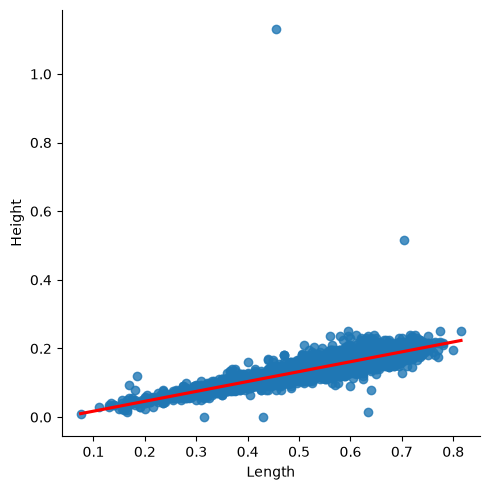

In [18]:
sns.lmplot(data=df, x = 'Length', y = 'Height', line_kws = {"color":"red"})

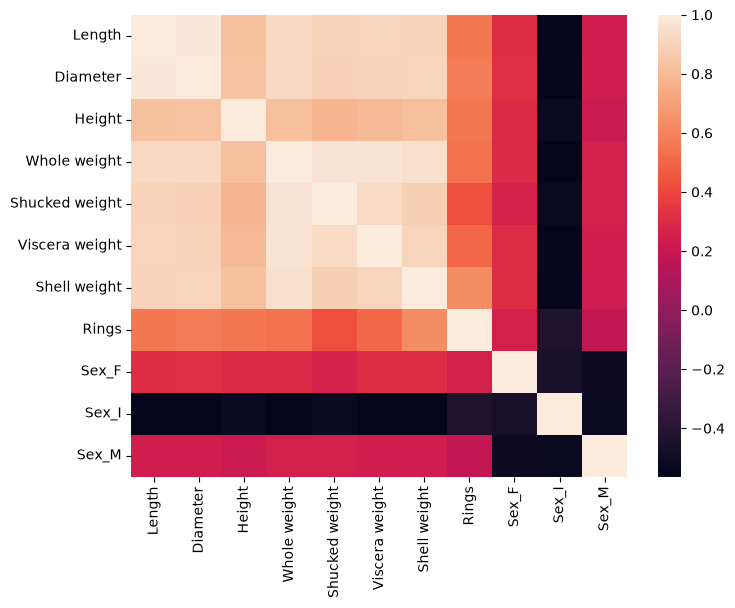

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_2.corr())
plt.show()

## **Data Preparation**

In [21]:
df_simple_linear = df [["Height","Length"]] # picking the features we need since we are focusing on a simple linear regression
df_simple_linear.head()

,Height,Length
0,0.095,0.455
1,0.090,0.350
2,0.135,0.530
3,0.125,0.440
4,0.080,0.330


In [23]:
df_2.shape

(4177, 11)

## **Modelling**

In [22]:
X_simple_linear = pd.DataFrame(df_simple_linear["Length"]) # independent variable
y_simple_linear = pd.DataFrame(df_simple_linear["Height"]) # target/ dependent variable

In [24]:

X_train, X_test, y_train, y_test = train_test_split(X_simple_linear, y_simple_linear , test_size=30, random_state= 42)

In [25]:

linear_reg_model = LinearRegression() # creates an instance of the model
linear_reg_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
linear_reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.29]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Length']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.01]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [27]:
X_test

,Length
866,0.605
1483,0.590
599,0.560
1702,0.635
670,0.475
2430,0.520
1590,0.520
949,0.480
4026,0.365
3668,0.585


In [28]:
linear_reg_model.predict(X_test)

array([[0.16287853],
       [0.15855394],
       [0.14990476],
       [0.17152771],
       [0.12539875],
       [0.13837252],
       [0.13837252],
       [0.12684028],
       [0.0936851 ],
       [0.15711241],
       [0.15711241],
       [0.09224357],
       [0.12684028],
       [0.0936851 ],
       [0.13116487],
       [0.15134629],
       [0.15567088],
       [0.1470217 ],
       [0.19026759],
       [0.1326064 ],
       [0.19747524],
       [0.19170912],
       [0.16720312],
       [0.16864465],
       [0.15999547],
       [0.11386651],
       [0.13837252],
       [0.13693099],
       [0.15422935],
       [0.13548946]])

In [30]:
y_predicted=linear_reg_model.predict(X_test)

In [31]:
y_test

,Height
866,0.160
1483,0.150
599,0.195
1702,0.170
670,0.145
2430,0.140
1590,0.130
949,0.115
4026,0.090
3668,0.145


In [32]:
y_predicted

array([[0.16287853],
       [0.15855394],
       [0.14990476],
       [0.17152771],
       [0.12539875],
       [0.13837252],
       [0.13837252],
       [0.12684028],
       [0.0936851 ],
       [0.15711241],
       [0.15711241],
       [0.09224357],
       [0.12684028],
       [0.0936851 ],
       [0.13116487],
       [0.15134629],
       [0.15567088],
       [0.1470217 ],
       [0.19026759],
       [0.1326064 ],
       [0.19747524],
       [0.19170912],
       [0.16720312],
       [0.16864465],
       [0.15999547],
       [0.11386651],
       [0.13837252],
       [0.13693099],
       [0.15422935],
       [0.13548946]])

In [33]:

r2_score(y_test, y_predicted)

0.7584762086566875